In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False

In [19]:
# 1. 추출기 가동 (어제 하루치 데이터만 가져오기)
# extractor는 이미 위에서 선언했다고 가정합니다.
target_tags = [
    'Emergency_Sw', '전진_Actual_Wagon_Num', 'g_s_SV_P1', 
    'Ana_Out_P1', 'Scale_Out___PT_P1', 'Scale_Out___FT_P1', 'TK_Temp_PV_P1', 'TK_Level_PV_P1'
]

In [4]:
from datetime import datetime, timedelta
from Log_Extractor import LogExtractor

extractor = LogExtractor()
# -24h 로 하루치만 가볍게 뽑습니다.
All_df = extractor.get_data(start_time="2026-04-05T22:00:00Z", end_time="2026-04-06T15:00:00Z", target_tags=None)

# 결측치 방어를 위해 앞선 값으로 채우기
df = All_df.ffill().fillna(0).copy()

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🔍 데이터 추출 시작... (2026-04-05T22:00:00Z ~ 2026-04-06T15:00:00Z)
✅ 추출 완료! 총 29731행, 1468개 컬럼 확보.


In [20]:
# -24h 로 하루치만 가볍게 뽑습니다.
raw_df = extractor.get_data(start_time="2026-04-05T22:00:00Z", end_time="2026-04-06T15:00:00Z", target_tags=target_tags)

# 결측치 방어를 위해 앞선 값으로 채우기
df = raw_df.ffill().fillna(0).copy()

🔍 데이터 추출 시작... (2026-04-05T22:00:00Z ~ 2026-04-06T15:00:00Z)
✅ 추출 완료! 총 29731행, 8개 컬럼 확보.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 세팅
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False 

# 0. 시작점: 결측치 채우고 시간 인덱스를 컬럼으로 빼주기 (에러 해결 핵심!)
df = raw_df.ffill().fillna(0).copy()
df_reset = df.reset_index() # 인덱스(Time)를 일반 컬럼으로 꺼냅니다.

# 1. 대차 번호(Wagon_Num)가 변하는 순간을 캐치하여 블록 ID 부여
df_reset['Wagon_Block_ID'] = (df_reset['전진_Actual_Wagon_Num'].diff() != 0).cumsum()

# 2. 각 블록별 요약 정보 만들기 (시간이 얼마나 걸렸나? 최대 SV값은? 등)
block_summary = df_reset.groupby('Wagon_Block_ID').agg(
    Wagon_Num=('전진_Actual_Wagon_Num', 'first'),
    Max_SV=('g_s_SV_P1', 'max'),
    Max_Ana_Out=('Ana_Out_P1', 'max'),
    # 'index' 대신 꺼내놓은 'Time' 컬럼을 사용해서 깐깐한 Pandas를 달래줍니다.
    Duration=('Time', lambda x: x.max() - x.min()) 
)

# 3. 진짜 쏘는 구간(Valid Block)만 필터링!
# 조건 A: 5분 이상 뻗어있는 노이즈(대기) 구간 컷 (Duration < 5분)
# 조건 B: 안 쏘고 그냥 지나가는 빈 대차 컷 (Max_SV > 10)
valid_blocks = block_summary[
    (block_summary['Duration'] < pd.Timedelta(minutes=5)) &
    (block_summary['Max_SV'] > 10)
].copy()

# 4. 이전 SV 값(Prev_SV) 구하기
valid_blocks['Prev_SV'] = valid_blocks['Max_SV'].shift(1)

# 5. 원본 df_reset에서 진짜 블록 + Emergency_Sw == 1 인 놈들만 최종 추출
valid_block_ids = valid_blocks.index
df_shots = df_reset[
    (df_reset['Wagon_Block_ID'].isin(valid_block_ids)) & 
    (df_reset['Emergency_Sw'] == 1)
].copy()

# 원본 데이터에 Prev_SV 정보 맵핑
df_shots = df_shots.merge(valid_blocks[['Prev_SV']], left_on='Wagon_Block_ID', right_index=True, how='left')

print("✅ 데이터 클리닝 및 윈도우(Window) 분할 완료!")
print(f"✅ 총 {len(valid_blocks)}개의 진짜 발포 사이클을 확보했습니다.")

✅ 데이터 클리닝 및 윈도우(Window) 분할 완료!
✅ 총 4200개의 진짜 발포 사이클을 확보했습니다.


🎯 분석 타겟 목표량(SV): 2340.0 g/s


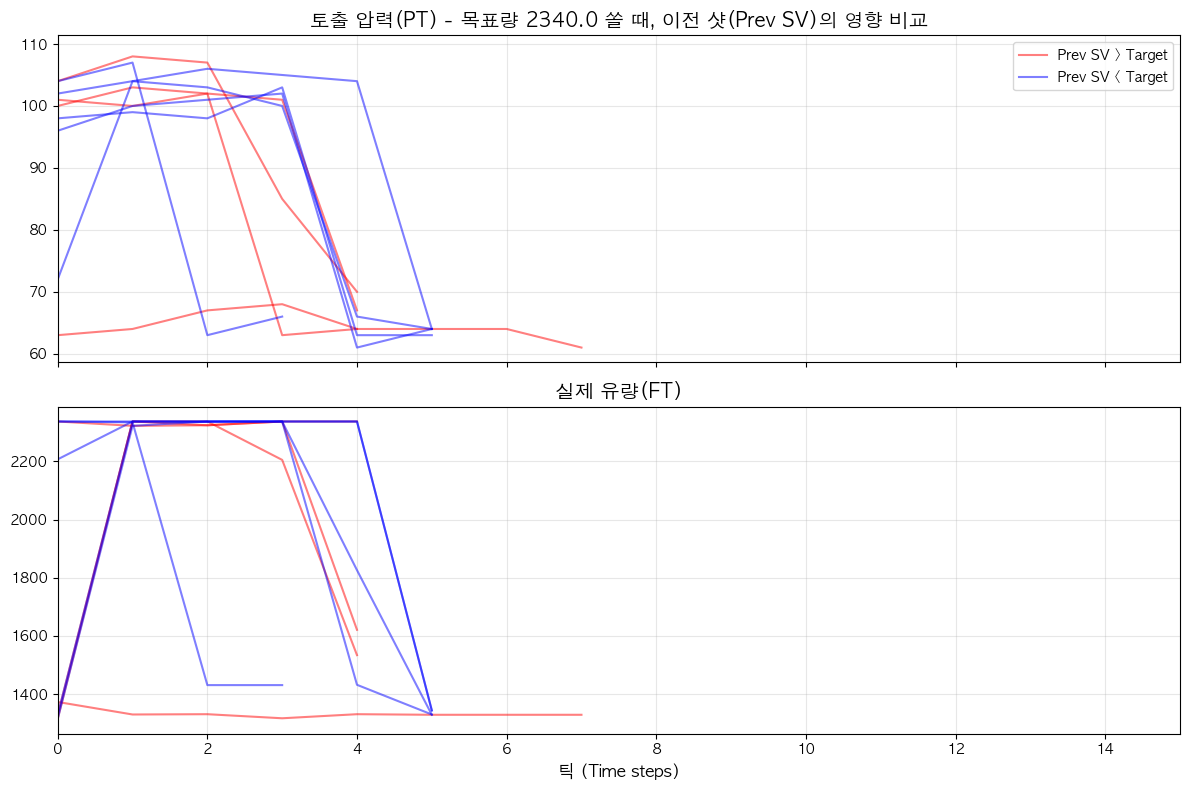

In [17]:
# 분석할 타겟 목표량 (가장 많이 쏜 양으로 자동 세팅)
target_sv = valid_blocks['Max_SV'].mode()[0]
print(f"🎯 분석 타겟 목표량(SV): {target_sv} g/s")

# 타겟 SV를 쏜 블록들만 필터링
df_target = df_shots[df_shots['g_s_SV_P1'] == target_sv]

# 이전 샷(Prev_SV)이 현재 타겟보다 컸던 놈(Down-step) / 작았던 놈(Up-step) 분리
# (각각 앞에서부터 5개씩만 뽑아봅니다)
high_prev_ids = df_target[df_target['Prev_SV'] > target_sv]['Wagon_Block_ID'].unique()[:5]
low_prev_ids = df_target[df_target['Prev_SV'] < target_sv]['Wagon_Block_ID'].unique()[:5]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 1. 직전에 큰 양을 쏘고 온 경우 (빨간색)
for wid in high_prev_ids:
    cycle_df = df_target[df_target['Wagon_Block_ID'] == wid].copy()
    x_axis = np.arange(len(cycle_df)) # X축 틱(0, 1, 2...) 생성
    
    axes[0].plot(x_axis, cycle_df['Scale_Out___PT_P1'], color='red', alpha=0.5, 
                 label='Prev SV > Target' if wid == high_prev_ids[0] else "")
    axes[1].plot(x_axis, cycle_df['Scale_Out___FT_P1'], color='red', alpha=0.5)

# 2. 직전에 적은 양을 쏘고 온 경우 (파란색)
for wid in low_prev_ids:
    cycle_df = df_target[df_target['Wagon_Block_ID'] == wid].copy()
    x_axis = np.arange(len(cycle_df)) 
    
    axes[0].plot(x_axis, cycle_df['Scale_Out___PT_P1'], color='blue', alpha=0.5, 
                 label='Prev SV < Target' if wid == low_prev_ids[0] else "")
    axes[1].plot(x_axis, cycle_df['Scale_Out___FT_P1'], color='blue', alpha=0.5)

axes[0].set_title(f"토출 압력(PT) - 목표량 {target_sv} 쏠 때, 이전 샷(Prev SV)의 영향 비교", fontsize=14)
axes[1].set_title("실제 유량(FT)", fontsize=14)
axes[1].set_xlabel("틱 (Time steps)", fontsize=12)

axes[0].legend()
for ax in axes:
    ax.grid(True, alpha=0.3)
    # 진짜 쏘는 구간인 약 15틱까지만 집중해서 봅니다.
    ax.set_xlim(0, 15) 

plt.tight_layout()
plt.show()

In [70]:
import numpy as np
import pandas as pd

# 데이터가 시간 순서대로 정렬되어 있는지 확실히 보장합니다.
df_shots = df_shots.sort_index()

model_df = df_shots.copy()

# ==========================================
# ⏱️ 1. 실시간 시퀀스 피처 (Tick Index)
# ==========================================
# 각 블록(샷) 내에서 0부터 시작하여 1씩 증가하는 틱 인덱스를 만듭니다.
model_df['Tick_Index'] = model_df.groupby('Wagon_Block_ID').cumcount()

# [신규 추가] 틱(Tick) 기반 Phase(구간) 피처 생성 (원핫 인코딩 형태)
# 틱 0~2까지는 과도기(Start), 3부터는 안정기(Steady)로 정의
model_df['Phase_Start'] = np.where(model_df['Tick_Index'] <= 2, 1.0, 0.0)
model_df['Phase_Steady'] = np.where(model_df['Tick_Index'] > 2, 1.0, 0.0)

# ==========================================
# 🎯 2. 오차 및 정규화 피처 (Error & Ratio)
# ==========================================
# 단순 오차량
model_df['Instant_FT_Error'] = model_df['g_s_SV_P1'] - model_df['Scale_Out___FT_P1']

# [질문 반영] 정규화된 오차율 (%) - 0으로 나누는 에러 방지
model_df['Instant_FT_Error_Rate'] = np.where(
    model_df['g_s_SV_P1'] > 0, 
    (model_df['Instant_FT_Error'] / model_df['g_s_SV_P1']) * 100, 
    0
)

# 블록별 누적 오차량 (현재 틱까지 펌프가 얼마나 덜 뿜어냈는가?)
model_df['Cum_FT_Error'] = model_df.groupby('Wagon_Block_ID')['Instant_FT_Error'].cumsum()

# ==========================================
# 📊 3. 맥락 및 추세 피처 (Context & Rolling)
# ==========================================
# [질문 반영] Prev_SV는 앞선 코드에서 이미 병합되어 있음. (단차 피처만 추가)
model_df['Prev_SV_Diff'] = model_df['g_s_SV_P1'] - model_df['Prev_SV'].fillna(0)

# 최근 3틱(약 6초) 동안의 최대 압력 (이동 최대값)
# min_periods=1로 설정하여 틱이 1~2개밖에 안 쌓인 초반에도 NaN이 뜨지 않게 합니다.
model_df['Rolling_PT_Max_3'] = model_df.groupby('Wagon_Block_ID')['Scale_Out___PT_P1'].rolling(window=3, min_periods=1).max().reset_index(0, drop=True)

# 최근 3틱 동안의 압력 변화량 (현재 압력 - 3틱 전 압력)
# 펌프가 막혀서 압력이 급상승하는 징후를 실시간으로 캐치합니다.
model_df['Rolling_PT_Diff_3'] = model_df.groupby('Wagon_Block_ID')['Scale_Out___PT_P1'].diff(periods=2).fillna(0)

# .diff()를 쓰면 SV가 2980 -> 2340으로 변한 순간 -640이 찍힙니다.
model_df['Instant_SV_Diff'] = model_df['g_s_SV_P1'].diff().fillna(0)
# [신규 추가] SV가 변한 바로 그 틱을 '전환기'로 원핫 인코딩
model_df['Phase_Transition'] = np.where(model_df['Instant_SV_Diff'] != 0, 1.0, 0.0)



# ==========================================
# 🧹 4. 최종 모델 입력용 컬럼 정리
# ==========================================
final_features = [
    'Wagon_Block_ID', 'Tick_Index',              # 메타 정보
    'g_s_SV_P1', 'Prev_SV', 'Prev_SV_Diff',      # 목표 및 맥락 정보
    'Ana_Out_P1', 'TK_Temp_PV_P1',               # 환경 및 지령치
    'Scale_Out___PT_P1', 'Rolling_PT_Max_3', 'Rolling_PT_Diff_3', # 압력 상태 (Stress)
    'Scale_Out___FT_P1', 'Instant_FT_Error_Rate', 'Cum_FT_Error',  # 유량 상태 (Performance)
    'Phase_Start', 'Phase_Steady', 'Phase_Transition'             # Phase 상태
]

model_df = model_df[final_features]

print("✅ 실시간 예측용 피처 엔지니어링 완료!")
print(model_df.head(10).to_string())

✅ 실시간 예측용 피처 엔지니어링 완료!
     Wagon_Block_ID  Tick_Index  g_s_SV_P1  Prev_SV  Prev_SV_Diff  Ana_Out_P1  TK_Temp_PV_P1  Scale_Out___PT_P1  Rolling_PT_Max_3  Rolling_PT_Diff_3  Scale_Out___FT_P1  Instant_FT_Error_Rate  Cum_FT_Error  Phase_Start  Phase_Steady  Phase_Transition
283              39           0     2980.0   2440.0         540.0      5333.0           21.0               69.0              69.0                0.0             1329.0              55.402685        1651.0          1.0           0.0               0.0
284              39           1     2980.0   2440.0         540.0      5333.0           21.0               66.0              69.0                0.0             1329.0              55.402685        3302.0          1.0           0.0               0.0
285              39           2     2980.0   2440.0         540.0      5333.0           21.0               67.0              69.0               -2.0             1329.0              55.402685        4953.0          1.0          

In [72]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. 학습에 사용할 진짜 피처들만 선택
feature_cols = [
    'g_s_SV_P1', 'Prev_SV', 'Prev_SV_Diff', 
    'Ana_Out_P1', 'TK_Temp_PV_P1',               
    'Scale_Out___PT_P1', 'Rolling_PT_Max_3', 'Rolling_PT_Diff_3', 
    'Scale_Out___FT_P1', 'Instant_FT_Error_Rate', 'Cum_FT_Error',
    'Phase_Start', 'Phase_Steady', 'Phase_Transition'  
]

# 2. 스케일링 (평균 0, 분산 1로 정규화)
# 나중에 실시간 추론할 때 써야 하므로 이 scaler 객체는 꼭 저장해둬야 합니다!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(model_df[feature_cols])

# 3. PyTorch가 좋아하는 Tensor 형태로 변환
# (오토인코더는 자기 자신을 복원하므로 X가 곧 정답(Y)입니다)
X_tensor = torch.FloatTensor(X_scaled)

# DataLoader 생성 (배치 단위로 쪼개서 먹이기 위함)
dataset = TensorDataset(X_tensor, X_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"✅ 모델에 들어갈 Tensor 변환 완료! 형태: {X_tensor.shape}")

✅ 모델에 들어갈 Tensor 변환 완료! 형태: torch.Size([26165, 14])


In [73]:
class PumpAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(PumpAutoencoder, self).__init__()
        
        # 데이터를 압축하는 과정 (11개 -> 4개)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU()
        )
        
        # 데이터를 다시 복원하는 과정 (4개 -> 11개)
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# 피처 개수(11개)만큼 input_dim 설정
input_dim = len(feature_cols)
model = PumpAutoencoder(input_dim)

# 손실 함수(오차 계산)와 최적화 도구(학습 알고리즘) 설정
criterion = nn.MSELoss() # 평균 제곱 오차
optimizer = optim.Adam(model.parameters(), lr=0.005)

print(model)

PumpAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=14, bias=True)
  )
)


In [74]:
epochs = 50 # 50바퀴 정도면 충분합니다.

print("🏃‍♂️ 학습 시작...")
for epoch in range(epochs):
    total_loss = 0
    for batch_x, batch_y in dataloader:
        
        optimizer.zero_grad()        # 1. 이전 기울기 초기화
        outputs = model(batch_x)     # 2. 모델에 넣고 복원(예측)
        loss = criterion(outputs, batch_y) # 3. 원본(batch_y)과의 오차 계산
        
        loss.backward()              # 4. 오차를 역전파해서 학습
        optimizer.step()             # 5. 가중치 업데이트
        
        total_loss += loss.item()
    
    # 10바퀴마다 경과 출력
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(dataloader):.4f}")

print("✅ 학습 완료! 펌프의 정상 궤적을 완벽히 외웠습니다.")

🏃‍♂️ 학습 시작...
Epoch [10/50], Loss: 0.2256
Epoch [20/50], Loss: 0.1937
Epoch [30/50], Loss: 0.1500
Epoch [40/50], Loss: 0.1493
Epoch [50/50], Loss: 0.1494
✅ 학습 완료! 펌프의 정상 궤적을 완벽히 외웠습니다.


In [75]:
import torch
import numpy as np
import pandas as pd

# ==========================================
# 🚨 함수 1: 실시간 이상 탐지 (점수 계산)
# ==========================================
def detect_anomaly(model, scaler, tick_df, feature_cols):
    """
    들어온 1틱의 데이터에 대해 건강도(오차 점수)와 변수별 오차량을 계산합니다.
    """
    model.eval() # 추론 모드 (Dropout 등 비활성화)
    with torch.no_grad(): # 실시간 추론 시에는 기울기 계산을 꺼서 메모리와 속도를 아낍니다.
        # 1. 스케일링
        scaled_data = scaler.transform(tick_df[feature_cols])
        tensor_data = torch.FloatTensor(scaled_data)
        
        # 2. 모델 복원
        reconstructed = model(tensor_data)
        
        # 3. 전체 오차(MSE) 계산 -> 이것이 '이상 점수(Anomaly Score)'가 됩니다.
        mse_loss = torch.mean((tensor_data - reconstructed) ** 2).item()
        
        # 4. 변수별 절대 오차 계산 (나중에 범인 잡을 때 씁니다)
        # 차원(1, 11)을 1차원(11,)으로 펴줍니다.
        feature_errors = torch.abs(tensor_data - reconstructed).numpy()[0] 
        
    return mse_loss, feature_errors


# ==========================================
# 📦 함수 2: 문맥 데이터 추출 (Context Window)
# ==========================================
def extract_context_data(buffer_df, current_idx, lookback=5):
    """
    이상이 발생했을 때, 룰 기반 판단을 위해 '해당 틱 포함 이전 N개의 틱'을 묶어서 가져옵니다.
    실시간 환경이므로 미래 데이터는 볼 수 없고, 직전 궤적(Lookback)을 봅니다.
    """
    # 버퍼(최근 데이터가 쌓이는 곳)에서 현재 인덱스 기준 lookback만큼 가져옵니다.
    start_idx = max(0, current_idx - lookback + 1)
    context_df = buffer_df.iloc[start_idx : current_idx + 1].copy()
    
    return context_df


# ==========================================
# 🕵️‍♂️ 함수 3: 범인 색출 (Feature Attribution)
# ==========================================
def identify_culprit(feature_errors, feature_cols, top_k=3):
    """
    변수별 오차량을 바탕으로 이번 이상 수치에 가장 크게 기여한 Top K 범인을 뽑아냅니다.
    """
    total_error = np.sum(feature_errors)
    if total_error == 0:
        return pd.DataFrame() # 에러가 0이면 범인도 없음
    
    # 각 변수가 전체 에러에서 차지하는 지분(%) 계산
    contributions = (feature_errors / total_error) * 100
    
    # 보기 좋게 데이터프레임으로 묶고 기여도 순으로 정렬
    culprit_df = pd.DataFrame({
        'Feature': feature_cols,
        'Error_Contribution(%)': contributions
    }).sort_values(by='Error_Contribution(%)', ascending=False)
    
    # 가장 심각한 놈들(top_k)만 리턴
    return culprit_df.head(top_k)

In [76]:
import pandas as pd
import numpy as np
import torch

class RealTimePreprocessor:
    def __init__(self, scaler, feature_cols):
        """
        초기화 단계: 학습할 때 썼던 스케일러와 컬럼 순서를 넘겨받아 저장합니다.
        """
        self.scaler = scaler
        self.feature_cols = feature_cols
        
        # 🧠 상태 기억용 변수들 (Memory)
        self.current_wagon_num = None  # 지금 지나가고 있는 대차 번호
        self.tick_index = -1           # 현재 샷의 틱 카운트
        self.prev_sv = 0.0             # 직전 샷의 SV 값
        self.current_max_sv = 0.0      # 이번 샷에서 관측된 최대 SV
        self.cum_ft_error = 0.0        # 누적 유량 오차
        self.pt_history = []           # 최근 3틱의 PT 값을 담아둘 리스트

        self.last_tick_sv = None

    def process_raw_tick(self, raw_tick):
        """
        1줄짜리 Raw 데이터(Series 또는 Dict)가 들어오면 피처를 추출하고 스케일링합니다.
        """
        # 1. Raw 값 추출
        wagon_num = raw_tick['전진_Actual_Wagon_Num']
        sv = raw_tick['g_s_SV_P1']
        pt = raw_tick['Scale_Out___PT_P1']
        ft = raw_tick['Scale_Out___FT_P1']
        
        # 2. 대차 번호가 바뀌었는지 체크 (새로운 샷의 시작)
        if self.current_wagon_num != wagon_num:
            # 상태 리셋 및 갱신
            self.prev_sv = self.current_max_sv # 이전 샷의 최대 SV를 백업
            self.current_wagon_num = wagon_num
            self.tick_index = 0
            self.current_max_sv = sv
            self.cum_ft_error = 0.0
            self.pt_history = []
        else:
            self.tick_index += 1
            if sv > self.current_max_sv:
                self.current_max_sv = sv
                
        # 3. 실시간 파생 피처(Feature) 계산
        instant_ft_error = sv - ft
        instant_ft_error_rate = (instant_ft_error / sv * 100) if sv > 0 else 0.0
        self.cum_ft_error += instant_ft_error
        
        self.pt_history.append(pt)
        if len(self.pt_history) > 3:
            self.pt_history.pop(0) # 가장 오래된 값 쳐내기 (항상 3개 유지)
            
        rolling_pt_max_3 = max(self.pt_history)
        # 3틱 전 데이터가 없으면 현재 pt와의 차이는 0, 있으면 (현재 - 3틱 전)
        rolling_pt_diff_3 = pt - self.pt_history[0] if len(self.pt_history) > 1 else 0.0

        # ------------------------------------------------
        # [추가] 3.5. 틱(Tick) 기반 Phase(구간) 피처 생성
        # ------------------------------------------------
        # 틱 0~2까지는 과도기(Start), 3부터는 안정기(Steady)로 정의
        phase_start = 1.0 if self.tick_index <= 2 else 0.0
        phase_steady = 1.0 if self.tick_index > 2 else 0.0

        # [신규 추가] 직전 틱 대비 SV 변화량 계산 (Transition 캐치)
        if self.last_tick_sv is None:
            instant_sv_diff = 0.0
        else:
            instant_sv_diff = sv - self.last_tick_sv
            
        phase_transition = 1.0 if instant_sv_diff != 0 else 0.0
        
        # 다음 틱을 위해 현재 SV 값을 기억 장치에 저장
        self.last_tick_sv = sv

        # 4. 모델 입력용 데이터 딕셔너리 조립
        processed_data = {
            'g_s_SV_P1': sv,
            'Prev_SV': self.prev_sv,
            'Prev_SV_Diff': sv - self.prev_sv,
            'Ana_Out_P1': raw_tick['Ana_Out_P1'],
            'TK_Temp_PV_P1': raw_tick['TK_Temp_PV_P1'],
            'Scale_Out___PT_P1': pt,
            'Rolling_PT_Max_3': rolling_pt_max_3,
            'Rolling_PT_Diff_3': rolling_pt_diff_3,
            'Scale_Out___FT_P1': ft,
            'Instant_FT_Error_Rate': instant_ft_error_rate,
            'Cum_FT_Error': self.cum_ft_error,
            'Phase_Start': phase_start,
            'Phase_Steady': phase_steady,
            'Phase_Transition': phase_transition
        }
        
        # 5. 스케일링 (학습 데이터와 동일한 순서 유지)
        df_processed = pd.DataFrame([processed_data])[self.feature_cols]
        scaled_data = self.scaler.transform(df_processed)
        
        # 6. PyTorch 텐서로 변환
        tensor_data = torch.FloatTensor(scaled_data)
        
        # 추론용 텐서, 시각화용 원본 피처 데이터, 메타 정보를 같이 리턴합니다.
        meta_info = {'Wagon_Num': wagon_num, 'Tick_Index': self.tick_index}
        return tensor_data, df_processed, meta_info

In [77]:
model.eval() # 모델을 추론 모드로 전환

PumpAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=14, bias=True)
  )
)

In [29]:
test_df = extractor.get_data(start_time="-10h", end_time="now()", target_tags=target_tags)

🔍 데이터 추출 시작... (-10h ~ now())
✅ 추출 완료! 총 17494행, 8개 컬럼 확보.


In [78]:
# 1. 전처리기 객체 생성 (학습할 때 만들었던 scaler와 feature_cols를 넣어줍니다)
# 14개의 펌프를 돌린다면 이 객체를 14개 만들면 됩니다! (예: preprocessor_p1, preprocessor_p2...)
preprocessor = RealTimePreprocessor(scaler=scaler, feature_cols=feature_cols)

# 결과를 담을 빈 리스트
inference_results = []
# 시각화를 위해 처음 500개의 유효한 틱만 모아봅니다 (약 10~15대의 대차 분량)
valid_tick_count = 0
# 2. 실시간 시뮬레이션
# raw_df는 추출기에서 가져온 아무 가공도 안 된 쌩(Raw) 데이터프레임입니다.
print("📡 실시간 데이터 스트리밍 시작...")

for i in range(len(test_df)):
    raw_tick = test_df.iloc[i] # 진짜 딱 1줄씩 가져옴
    
    # [노이즈 필터링] 안 쏘거나 정지 중인 데이터는 스킵 (실시간 판단)
    if raw_tick['Emergency_Sw'] != 1 or raw_tick['g_s_SV_P1'] < 10:
        continue
        
    # ------------------------------------------------
    # 🎩 마법의 전처리기 통과!
    # ------------------------------------------------
    tensor_data, df_processed, meta_info = preprocessor.process_raw_tick(raw_tick)
    
    # ------------------------------------------------
    # 🤖 모델 추론
    # ------------------------------------------------
    model.eval()
    with torch.no_grad():
        reconstructed = model(tensor_data)
        mse_loss = torch.mean((tensor_data - reconstructed) ** 2).item()
        feature_errors = torch.abs(tensor_data - reconstructed).numpy()[0]
    
    # ★ 결과 저장 (그래프를 그리기 위해 핵심 데이터만 모읍니다)
    inference_results.append({
        'Wagon_Num': meta_info['Wagon_Num'],
        'Tick_Index': meta_info['Tick_Index'],
        'Loss': mse_loss,
        'Target_SV': df_processed['g_s_SV_P1'].values[0],
        'Actual_FT': df_processed['Scale_Out___FT_P1'].values[0],
        'Actual_PT': df_processed['Scale_Out___PT_P1'].values[0]
    })
    
    # 리스트를 데이터프레임으로 변환
    results_df = pd.DataFrame(inference_results)
    print(f"✅ 총 {len(results_df)}틱의 추론 결과 수집 완료!")
    
    if meta_info['Tick_Index'] == 10:
        break

📡 실시간 데이터 스트리밍 시작...
✅ 총 1틱의 추론 결과 수집 완료!
✅ 총 2틱의 추론 결과 수집 완료!
✅ 총 3틱의 추론 결과 수집 완료!
✅ 총 4틱의 추론 결과 수집 완료!
✅ 총 5틱의 추론 결과 수집 완료!
✅ 총 6틱의 추론 결과 수집 완료!
✅ 총 7틱의 추론 결과 수집 완료!
✅ 총 8틱의 추론 결과 수집 완료!
✅ 총 9틱의 추론 결과 수집 완료!
✅ 총 10틱의 추론 결과 수집 완료!
✅ 총 11틱의 추론 결과 수집 완료!
✅ 총 12틱의 추론 결과 수집 완료!
✅ 총 13틱의 추론 결과 수집 완료!
✅ 총 14틱의 추론 결과 수집 완료!
✅ 총 15틱의 추론 결과 수집 완료!
✅ 총 16틱의 추론 결과 수집 완료!
✅ 총 17틱의 추론 결과 수집 완료!
✅ 총 18틱의 추론 결과 수집 완료!
✅ 총 19틱의 추론 결과 수집 완료!
✅ 총 20틱의 추론 결과 수집 완료!
✅ 총 21틱의 추론 결과 수집 완료!
✅ 총 22틱의 추론 결과 수집 완료!
✅ 총 23틱의 추론 결과 수집 완료!
✅ 총 24틱의 추론 결과 수집 완료!
✅ 총 25틱의 추론 결과 수집 완료!
✅ 총 26틱의 추론 결과 수집 완료!
✅ 총 27틱의 추론 결과 수집 완료!
✅ 총 28틱의 추론 결과 수집 완료!
✅ 총 29틱의 추론 결과 수집 완료!
✅ 총 30틱의 추론 결과 수집 완료!
✅ 총 31틱의 추론 결과 수집 완료!
✅ 총 32틱의 추론 결과 수집 완료!
✅ 총 33틱의 추론 결과 수집 완료!
✅ 총 34틱의 추론 결과 수집 완료!
✅ 총 35틱의 추론 결과 수집 완료!
✅ 총 36틱의 추론 결과 수집 완료!
✅ 총 37틱의 추론 결과 수집 완료!
✅ 총 38틱의 추론 결과 수집 완료!
✅ 총 39틱의 추론 결과 수집 완료!
✅ 총 40틱의 추론 결과 수집 완료!
✅ 총 41틱의 추론 결과 수집 완료!
✅ 총 42틱의 추론 결과 수집 완료!
✅ 총 43틱의 추론 결과 수집 완료!
✅ 총 44틱의 추론 결과 수집 완료!
✅ 총 45틱의 추론 결과 수집 완료

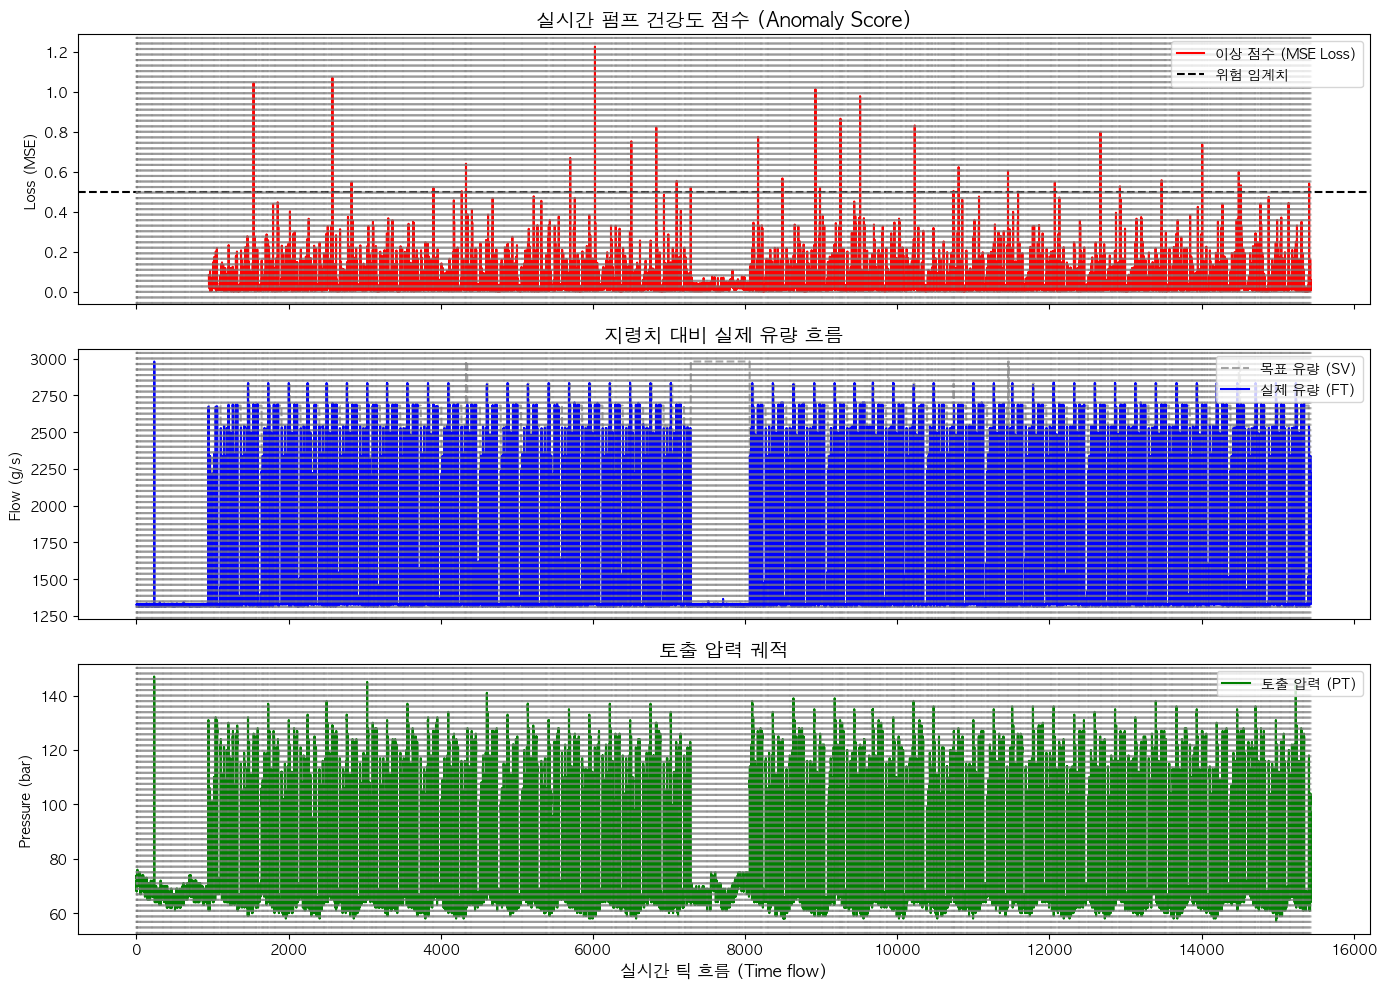

In [79]:
# ==========================================
# 2. 결과 시각화 (Loss vs 물리적 데이터)
# ==========================================
# 3개의 그래프를 위아래로 동기화해서 그립니다.
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# X축은 단순히 데이터가 들어온 순서(인덱스)로 둡니다.
x_axis = results_df.index

# [그래프 1] 오토인코더 이상 점수 (Loss)
axes[0].plot(x_axis, results_df['Loss'], color='red', label='이상 점수 (MSE Loss)')
# 임계치 가이드라인 (학습 데이터의 최대 loss를 보고 나중에 적절히 조절하세요. 임시로 0.5 세팅)
axes[0].axhline(y=0.5, color='black', linestyle='--', label='위험 임계치') 
axes[0].set_title('실시간 펌프 건강도 점수 (Anomaly Score)', fontsize=14)
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend(loc='upper right')

# [그래프 2] 목표 유량(SV) vs 실제 유량(FT)
axes[1].plot(x_axis, results_df['Target_SV'], color='gray', linestyle='--', label='목표 유량 (SV)', alpha=0.7)
axes[1].plot(x_axis, results_df['Actual_FT'], color='blue', label='실제 유량 (FT)')
axes[1].set_title('지령치 대비 실제 유량 흐름', fontsize=14)
axes[1].set_ylabel('Flow (g/s)')
axes[1].legend(loc='upper right')

# [그래프 3] 토출 압력(PT)
axes[2].plot(x_axis, results_df['Actual_PT'], color='green', label='토출 압력 (PT)')
axes[2].set_title('토출 압력 궤적', fontsize=14)
axes[2].set_ylabel('Pressure (bar)')
axes[2].set_xlabel('실시간 틱 흐름 (Time flow)', fontsize=12)
axes[2].legend(loc='upper right')

# 대차가 바뀔 때마다 세로선(Vertical line) 그어주기 (시각적 구분)
wagon_changes = results_df[results_df['Tick_Index'] == 0].index
for idx in wagon_changes:
    for ax in axes:
        ax.axvline(x=idx, color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

In [80]:
import time
# 1. 전처리기 객체 생성 (학습할 때 만들었던 scaler와 feature_cols를 넣어줍니다)
# 14개의 펌프를 돌린다면 이 객체를 14개 만들면 됩니다! (예: preprocessor_p1, preprocessor_p2...)
preprocessor = RealTimePreprocessor(scaler=scaler, feature_cols=feature_cols)

# 1. 설정값 세팅
THRESHOLD = 0.5  
LOOKBACK = 5     

realtime_buffer = [] 

print(f"🚀 [시스템 가동] 임계치 {THRESHOLD} 기반 실시간 감시 및 정밀 분석 시작...")
print("=" * 80)

anomaly_count = 0

for i in range(len(test_df)):
    raw_tick = test_df.iloc[i]
    
    # ⏱️ 핵심: 현재 데이터의 시간(Timestamp) 가져오기
    # 보통 InfluxDB에서 가져온 데이터프레임은 인덱스(name)가 시간입니다.
    current_time = raw_tick.name 
    
    # [필터링] 가동 중일 때만 분석
    if raw_tick['Emergency_Sw'] != 1 or raw_tick['g_s_SV_P1'] < 10:
        continue
        
    # 1. 전처리 통과
    tensor_data, df_processed, meta_info = preprocessor.process_raw_tick(raw_tick)

    # [추가된 로직] 현재 샷이 '콜드 스타트'인지 확인
    is_cold_start = False
    
    # 현재 버퍼에 이전 샷 기록이 있고, 현재 틱이 샷의 극초반(예: 0~2틱)일 때만 검사
    if len(realtime_buffer) > 0 and meta_info['Tick_Index'] <= 2:
        last_shot_time = realtime_buffer[-1]['Time'].iloc[0]
        current_time = raw_tick.name
        
        # 직전 데이터와 현재 데이터의 시간 차이가 3분(180초) 이상이면 콜드 스타트로 간주
        time_diff = (current_time - last_shot_time).total_seconds()
        if time_diff > 10:
            is_cold_start = True
    
    # 분석을 위해 버퍼에 저장할 때 시간 정보도 같이 넣습니다.
    current_record = df_processed.copy()
    current_record['Time'] = current_time  # 시간 컬럼 추가!
    current_record['Wagon_Num'] = meta_info['Wagon_Num']
    current_record['Tick_Index'] = meta_info['Tick_Index']
    realtime_buffer.append(current_record)
    
    # 2. 실시간 이상 탐지
    mse_score, feature_errors = detect_anomaly(model, scaler, df_processed, feature_cols)
    
    # 3. 이상 발생 시 정밀 진단
    if mse_score > THRESHOLD:
        if is_cold_start:
            # 점수가 높아도 알람을 울리지 않고 넘어갑니다. (로그만 가볍게 남김)
            # print(f"🕒 [콜드 스타트 무시] 3분 이상 대기 후 첫 가동이라 알람을 생략합니다. (Time: {current_time})")
            continue
        anomaly_count += 1
        
        culprits = identify_culprit(feature_errors, feature_cols, top_k=3)
        
        buffer_df = pd.concat(realtime_buffer)
        context_df = extract_context_data(buffer_df, len(buffer_df)-1, lookback=LOOKBACK)
        
        # ------------------------------------------------
        # 📋 정밀 분석 리포트 출력 (시간 추가됨!)
        # ------------------------------------------------
        print(f"🚨 [ANOMALY DETECTED #{anomaly_count}]")
        # 보기 좋게 시간을 문자열 형식(YYYY-MM-DD HH:MM:SS)으로 출력
        formatted_time = current_time.strftime('%Y-%m-%d %H:%M:%S') if hasattr(current_time, 'strftime') else current_time
        print(f"⏰ 발생 시간: {formatted_time}")
        print(f"📍 발생 위치: 대차 번호 {meta_info['Wagon_Num']} | 샷 내 위치: {meta_info['Tick_Index']} 틱")
        print(f"📈 이상 점수(MSE): {mse_score:.4f} (위험 수준)")
        
        print(f"🕵️‍♂️ 범인 색출 결과 (Top 3 기여도):")
        for idx, row in culprits.iterrows():
            print(f"   - [{row['Feature']}] : {row['Error_Contribution(%)']:.1f}% 지분")
            
        print(f"📦 상황(Context) 데이터 (최근 {len(context_df)}틱 흐름):")
        # 상황 데이터 출력할 때도 시간(Time)을 맨 앞에 보여줍니다.
        display_cols = ['Time', 'Tick_Index', 'g_s_SV_P1', 'Scale_Out___PT_P1', 'Scale_Out___FT_P1', 'Instant_FT_Error_Rate']
        print(context_df[display_cols].to_string(index=False))
        
        print("-" * 80)
        
        if anomaly_count >= 5: # 이번엔 5개까지 넉넉하게 뽑아봅시다
            print("💡 초기 분석을 위해 5개의 케이스만 추출했습니다. 루프를 종료합니다.")
            break

if anomaly_count == 0:
    print("✅ 현재 데이터 구간에서는 임계치를 넘는 이상 징후가 발견되지 않았습니다.")

🚀 [시스템 가동] 임계치 0.5 기반 실시간 감시 및 정밀 분석 시작...
🚨 [ANOMALY DETECTED #1]
⏰ 발생 시간: 2026-04-07 07:11:25
📍 발생 위치: 대차 번호 20.0 | 샷 내 위치: 0 틱
📈 이상 점수(MSE): 1.0426 (위험 수준)
🕵️‍♂️ 범인 색출 결과 (Top 3 기여도):
   - [Prev_SV] : 25.6% 지분
   - [Ana_Out_P1] : 22.8% 지분
   - [g_s_SV_P1] : 19.8% 지분
📦 상황(Context) 데이터 (최근 5틱 흐름):
                      Time  Tick_Index  g_s_SV_P1  Scale_Out___PT_P1  Scale_Out___FT_P1  Instant_FT_Error_Rate
2026-04-07 07:11:16.611057           1     2680.0              122.0             2690.0              -0.373134
2026-04-07 07:11:18.883112           2     2680.0              120.0             2687.0              -0.261194
2026-04-07 07:11:21.461222           3     2680.0               63.0             2136.0              20.298507
2026-04-07 07:11:22.641749           4     2680.0               63.0             1329.0              50.410448
2026-04-07 07:11:25.178942           0     2680.0              119.0             1548.0              42.238806
----------------------------------

/var/folders/fj/zp006l253zsg23q736jqrh800000gn/T/ipykernel_44589/1385910145.py:55: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) AppleGothic.
  plt.tight_layout()


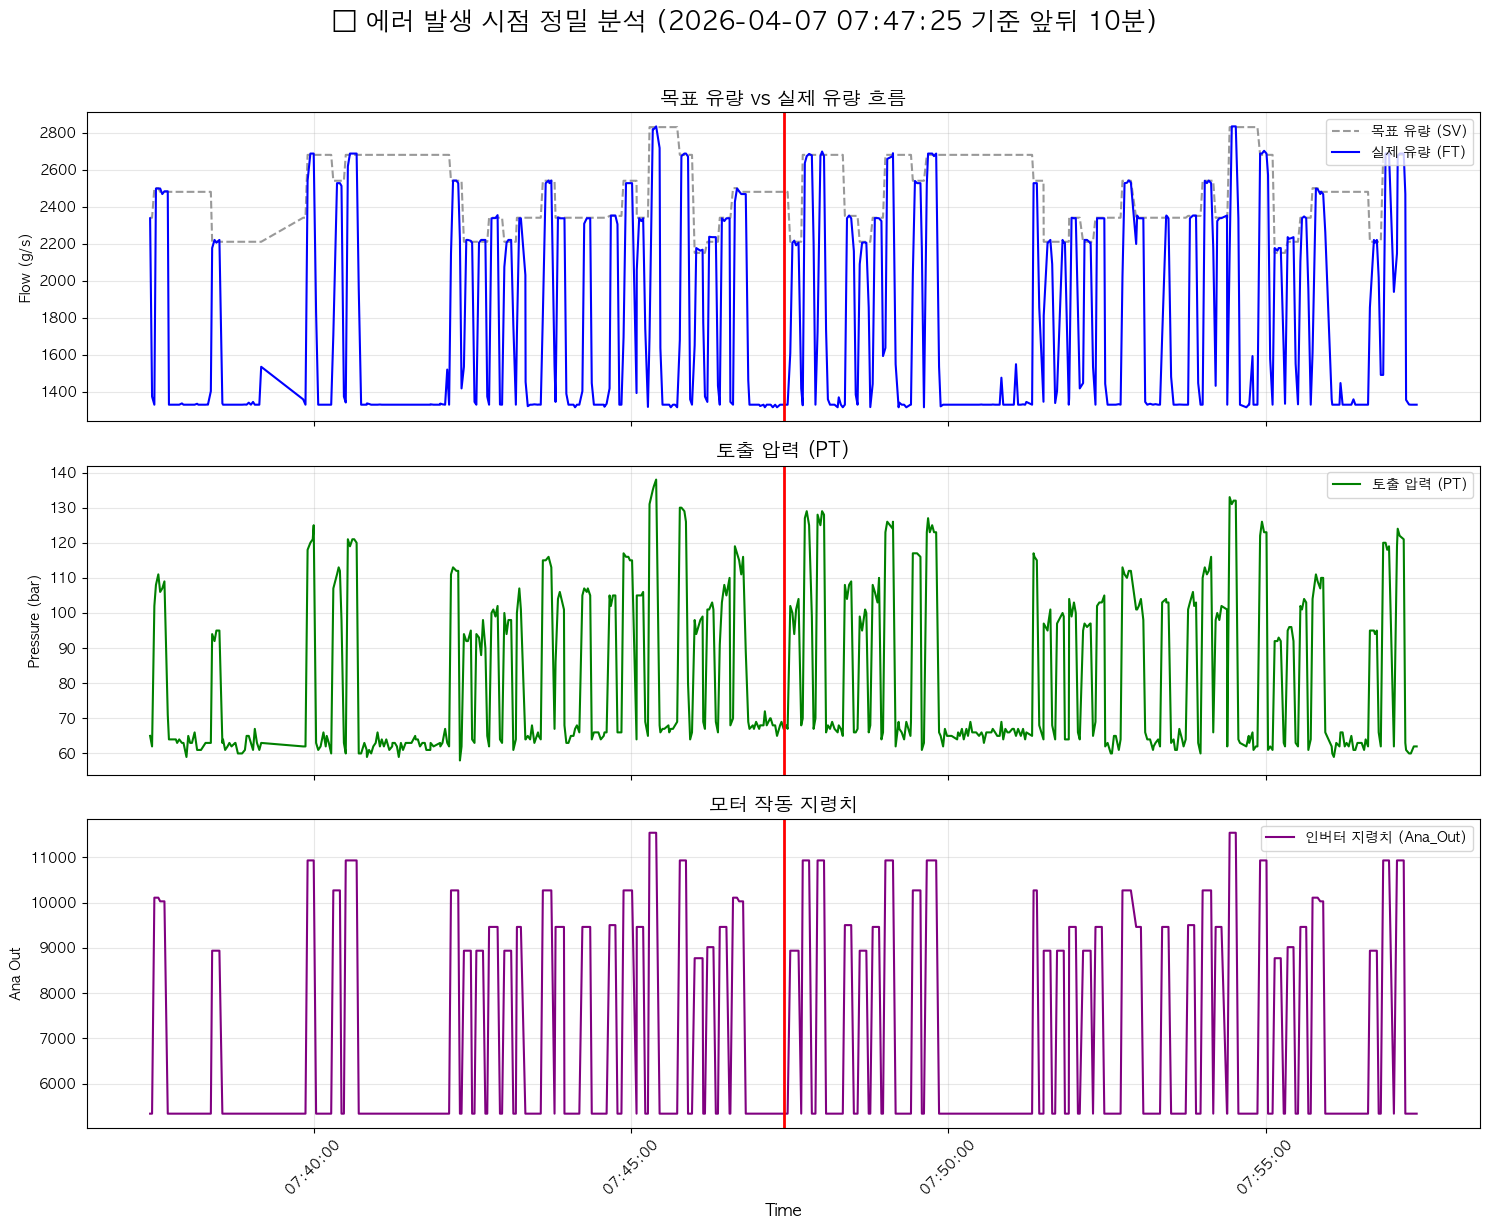

In [82]:
# ==========================================
# 🚀 사용 예시 (직접 실행해 보세요!)
# ==========================================
# 주의: raw_df의 인덱스가 DatetimeIndex인지 꼭 확인하세요! 
# (만약 에러 나면 raw_df.set_index('Time', inplace=True)를 먼저 실행해 주세요)

# 아까 리포트에서 뜬 시간을 여기에 복붙합니다.
target_time = "2026-04-07 07:47:25" # <-- 이 시간을 수정하세요!

# 함수 실행 (앞뒤 10분 보기)
plot_anomaly_context(test_df, target_time, window_minutes=10)

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_anomaly_context(df, target_time_str, window_minutes=10):
    """
    특정 시간을 기준으로 앞뒤 N분의 원시 데이터를 시각화합니다.
    """
    # 1. 시간 문자열을 Datetime 객체로 변환 (df 인덱스가 시간이라고 가정)
    target_dt = pd.to_datetime(target_time_str)
    start_dt = target_dt - pd.Timedelta(minutes=window_minutes)
    end_dt = target_dt + pd.Timedelta(minutes=window_minutes)
    
    # 2. 앞뒤 시간만큼 데이터 슬라이싱 (잘라내기)
    # 인덱스가 DatetimeIndex로 되어 있어야 정상 작동합니다.
    mask = (df.index >= start_dt) & (df.index <= end_dt)
    plot_df = df[mask].copy()
    
    if plot_df.empty:
        print(f"⚠️ 해당 시간대({start_dt} ~ {end_dt})의 데이터가 없습니다.")
        return
    
    # 3. 3단 콤보 그래프 그리기
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    x_axis = plot_df.index
    
    # [그래프 1] 유량 비교 (명령 vs 실제)
    axes[0].plot(x_axis, plot_df['g_s_SV_P1'], label='목표 유량 (SV)', color='gray', linestyle='--', alpha=0.8)
    axes[0].plot(x_axis, plot_df['Scale_Out___FT_P1'], label='실제 유량 (FT)', color='blue')
    axes[0].set_title(f"목표 유량 vs 실제 유량 흐름", fontsize=14)
    axes[0].set_ylabel('Flow (g/s)')
    
    # [그래프 2] 토출 압력
    axes[1].plot(x_axis, plot_df['Scale_Out___PT_P1'], label='토출 압력 (PT)', color='green')
    axes[1].set_title("토출 압력 (PT)", fontsize=14)
    axes[1].set_ylabel('Pressure (bar)')
    
    # [그래프 3] 인버터 지령치 (모터 속도)
    axes[2].plot(x_axis, plot_df['Ana_Out_P1'], label='인버터 지령치 (Ana_Out)', color='purple')
    axes[2].set_title("모터 작동 지령치", fontsize=14)
    axes[2].set_ylabel('Ana Out')
    axes[2].set_xlabel('Time', fontsize=12)
    
    # 🎯 공통 꾸미기: 에러 발생 시점에 빨간색 수직선 긋기!
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
        ax.axvline(x=target_dt, color='red', linestyle='-', linewidth=2, label='🔥 이상 감지 시점')
        
        # X축 시간 포맷팅 (HH:MM:SS 형태로 깔끔하게)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        
    plt.xticks(rotation=45)
    plt.suptitle(f"🔍 에러 발생 시점 정밀 분석 ({target_time_str} 기준 앞뒤 {window_minutes}분)", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()



In [71]:
extractor.save_to_csv(model_df, "real_time_test_data.csv")

💾 [저장 완료] 분석용 CSV 파일이 생성되었습니다: real_time_test_data.csv/2026-04-07_181133_analysis.csv


In [21]:
# ==========================================
# 1. 보고 싶은 태그 목록 세팅
# ==========================================
# (HMI 설정값 태그명은 실제 DB에 저장된 이름으로 정확히 맞춰주세요)
conv_tags = [
    "전진_Actual_Wagon_Num", 
    "후진_Actual_Wagon_Num", 
    "Now_Actual_Wagon_Num",
    "RB1_Robot_Num", 
    "RB2_Robot_Num",
    "Hz_In_Conv", 
    "Conv_SPD SET_HMI",
    "CONVEYOR RUN / STOP PL_HMI",
    "Conv_Slow_Out"
]

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 깨짐 방지 (Windows/Mac 공통)
import matplotlib.font_manager as fm
import os

plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

In [4]:
from Fast_Log_Ext import Fast_LogExtractor
extractor = Fast_LogExtractor()

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!


In [22]:
# ==========================================
# 2. 데이터 추출 (최근 3시간 데이터)
# ==========================================
# extractor 인스턴스가 있다고 가정
print("🔍 DB에서 데이터를 가져옵니다...")
df_vis = extractor.get_data(start_time="-6h", end_time="now()", target_tags=conv_tags)

🔍 DB에서 데이터를 가져옵니다...
🔍 데이터 추출 시작... (-6h ~ now())
✅ 추출 완료! 총 9991행, 9개 컬럼 확보.


In [7]:
# ==========================================
# 3. 데이터 시각화 함수 정의 및 실행
# ==========================================
def plot_conveyor_dynamics(df):
    if df.empty:
        print("⚠️ 데이터가 없습니다.")
        return

    # 결측치 처리 (이전 값으로 채우기)
    df = df.ffill().fillna(0)

    # 그래프 사이즈 설정 (세로로 긴 3단 그래프)
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [2, 1, 1.5]})
    plt.subplots_adjust(hspace=0.4)

    # --- [그래프 1] 시간에 따른 대차 번호와 컨베이어 속도 추이 ---
    ax1 = axes[0]
    ax1_twin = ax1.twinx()

    # 대차 번호 (계단형 그래프)
    ax1.plot(df.index, df['RB1_Robot_Num'], label='RB1 Robot Num', color='blue', alpha=0.6, drawstyle='steps-post')
    ax1.plot(df.index, df['전진_Actual_Wagon_Num'], label='전진 Wagon Num', color='cyan', alpha=0.4, drawstyle='steps-post', linestyle='--')
    
    # 컨베이어 속도 및 설정값
    if 'Conv_SPD SET_HMI' in df.columns:
        ax1_twin.plot(df.index, df['Conv_SPD SET_HMI'], label='Conv_SPD SET_HMI (목표)', color='orange', alpha=0.8, linewidth=2)
    ax1_twin.plot(df.index, df['Hz_In_Conv'], label='Hz_In_Conv (실제 속도)', color='red', alpha=0.8, linewidth=2)

    ax1.set_title("🕒 [Time Series] 대차 번호 변화와 컨베이어 속도 추이", fontsize=14, fontweight='bold')
    ax1.set_ylabel("대차 번호 (1~42)")
    ax1_twin.set_ylabel("속도 / 주파수 (Hz)")
    
    # 범례 합치기
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    # --- [그래프 2] 속도(Hz) 분포 히스토그램 ---
    ax2 = axes[1]
    sns.histplot(data=df, x='Hz_In_Conv', bins=50, kde=True, ax=ax2, color='coral')
    ax2.set_title("📊 [Distribution] 컨베이어 속도(Hz) 발생 빈도", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Hz_In_Conv")
    ax2.set_ylabel("빈도 (틱 수)")

    # --- [그래프 3] 대차 번호별 평균 속도 산점도/박스플롯 ---
    ax3 = axes[2]
    # 속도가 0 이상인 가동 중인 데이터만 필터링
    df_running = df[df['Hz_In_Conv'] > 5].copy()
    
    if not df_running.empty:
        sns.boxplot(data=df_running, x='RB1_Robot_Num', y='Hz_In_Conv', ax=ax3, palette='viridis')
        ax3.set_title("🎯 [Correlation] 대차 번호별 실제 컨베이어 속도 분포", fontsize=14, fontweight='bold')
        ax3.set_xlabel("RB1 Robot Num")
        ax3.set_ylabel("Hz_In_Conv")
        ax3.tick_params(axis='x', rotation=45)
    else:
        ax3.text(0.5, 0.5, "가동 중인 데이터가 없습니다.", ha='center')

    plt.show()

/var/folders/fj/zp006l253zsg23q736jqrh800000gn/T/ipykernel_3629/2793848112.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_running, x='RB1_Robot_Num', y='Hz_In_Conv', ax=ax3, palette='viridis')
/Users/jeonjae/Desktop/KTA/DB_Log/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128338 (\N{CLOCK FACE THREE OCLOCK}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonjae/Desktop/KTA/DB_Log/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonjae/Desktop/KTA/DB_Log/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) AppleGothic.
  fig.canvas.pr

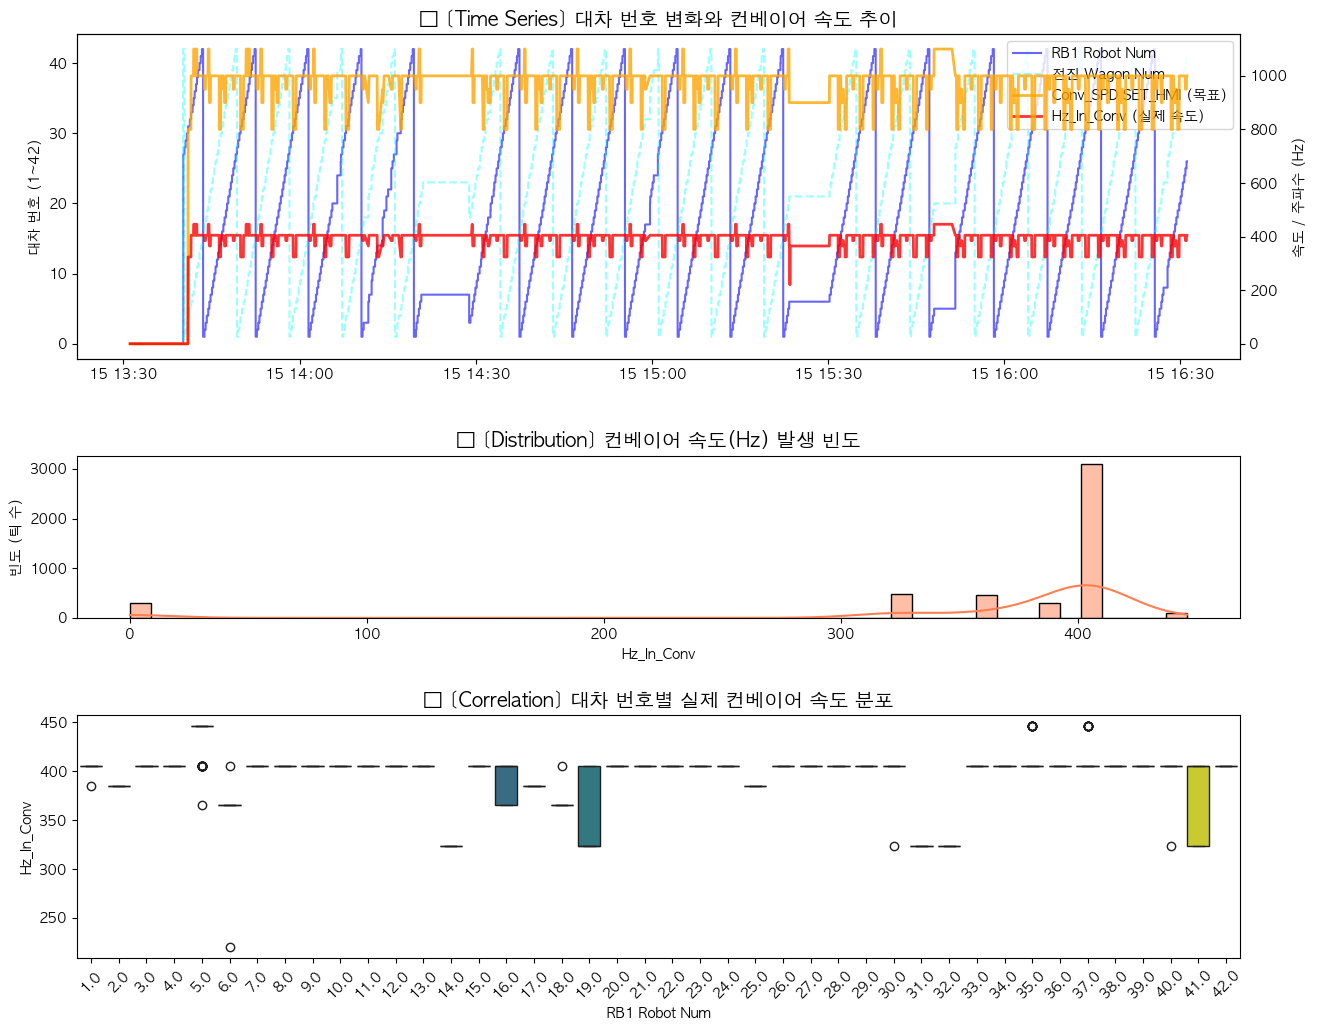

In [8]:
plot_conveyor_dynamics(df_vis)

In [20]:
if not df_vis.empty:
    # 결측치 채우기
    df = df_vis.ffill().fillna(0)

    # ==========================================
    # 2. 노이즈 제거 (가동 중인 상태만 필터링)
    # ==========================================
    # HMI 런 시그널이 1(가동)이고, 실제 주파수가 5Hz 이상인 '진짜 주행' 상태만 남김
    df_run = df[(df["CONVEYOR RUN / STOP PL_HMI"] == 1) & (df["Hz_In_Conv"] > 5)].copy()

    print(f"✂️ 필터링 완료: 전체 {len(df)}틱 중 실제 가동 데이터 {len(df_run)}틱 추출")

    if not df_run.empty:
        # ==========================================
        # 3. 분석 1: 대차 번호별 [실제 속도] 발생 빈도 (교차표)
        # ==========================================
        # 특정 대차가 지나갈 때 Hz_In_Conv가 몇 Hz로 몇 번 찍혔는지 센다.
        cross_tab = pd.crosstab(df_run['RB1_Robot_Num'], df_run['Hz_In_Conv'])
        
        print("\n📊 [분석 1] 대차 번호별 컨베이어 속도(Hz) 발생 횟수 매트릭스")
        print("-" * 60)
        print(cross_tab)
        print("-" * 60)

        # ==========================================
        # 4. 분석 2: 대차 번호별 [속도 통계 요약]
        # ==========================================
        # 대차별 평균 속도와 최소/최대 속도를 확인
        stats_df = df_run.groupby('RB1_Robot_Num').agg(
            데이터수=('Hz_In_Conv', 'count'),
            평균속도=('Hz_In_Conv', 'mean'),
            최소속도=('Hz_In_Conv', 'min'),
            최대속도=('Hz_In_Conv', 'max')
        ).round(1)

        print("\n📈 [분석 2] 대차 번호별 컨베이어 속도 통계")
        print("-" * 60)
        print(stats_df)
        print("-" * 60)

        # ==========================================
        # 5. (옵션) 형님 가설 검증용 상관계수
        # ==========================================
        # 대차 번호와 속도 간의 피어슨 상관계수 (-1 ~ 1)
        # 0에 가까우면 "대차 번호와 속도는 아무 상관 없다"
        # 1이나 -1에 가까우면 "대차 번호에 따라 속도가 변한다"
        correlation = df_run['RB1_Robot_Num'].corr(df_run['Hz_In_Conv'])
        print(f"\n🧠 [가설 검증] 대차 번호와 컨베이어 속도의 상관계수: {correlation:.3f}")
        
        if abs(correlation) < 0.1:
            print("👉 결론: 대차 번호와 속도는 거의 무관합니다. (제 분석이 맞을 확률 높음)")
        else:
            print("👉 결론: 대차 번호와 속도 사이에 유의미한 관계가 있습니다! (형님 가설 적중!)")

    else:
        print("⚠️ 가동 중인(RUN == 1) 데이터가 없습니다.")
else:
    print("⚠️ DB에서 데이터를 불러오지 못했습니다.")

✂️ 필터링 완료: 전체 9983틱 중 실제 가동 데이터 8467틱 추출

📊 [분석 1] 대차 번호별 컨베이어 속도(Hz) 발생 횟수 매트릭스
------------------------------------------------------------
Hz_In_Conv     220.0  324.0  365.0  385.0  405.0  446.0
RB1_Robot_Num                                          
1.0                0      0      0      2    194      0
2.0                0      0      0    205      0      0
3.0                0      0      0      0    198      0
4.0                0      0      0      0    194      0
5.0                0      0      1      0     39    142
6.0                1      0    224      0      1      0
7.0                0      0      0      0    200      0
8.0                0      0      0      0    192      0
9.0                0      0      0      0    196      0
10.0               0      0      0      0    191      0
11.0               0      0      0      0    196      0
12.0               0      0      0      0    190      0
13.0               0      1      0      0    194      0
14.0              

In [14]:
df_vis

,전진_Actual_Wagon_Num,후진_Actual_Wagon_Num,Now_Actual_Wagon_Num,RB1_Robot_Num,RB2_Robot_Num,Hz_In_Conv,Conv_SPD SET_HMI
Time,,,,,,,
2026-04-15 10:38:02.475094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-15 10:38:04.745409,38.0,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-15 10:38:07.660090,38.0,24.0,23.0,23.0,NaN,NaN,NaN
2026-04-15 10:38:09.001461,38.0,24.0,23.0,23.0,NaN,NaN,NaN
2026-04-15 10:38:11.012304,38.0,24.0,23.0,23.0,23.0,NaN,NaN
...,...,...,...,...,...,...,...
2026-04-15 16:37:52.365463,30.0,16.0,15.0,15.0,15.0,405.0,1000.0
2026-04-15 16:37:54.359478,30.0,16.0,15.0,15.0,15.0,405.0,1000.0
2026-04-15 16:37:56.656893,31.0,16.0,15.0,15.0,15.0,405.0,1000.0


In [28]:
import pandas as pd
import numpy as np

if not df_vis.empty:
    df = df_vis.ffill().fillna(0)

    # ==========================================
    # 2. 노이즈 1차 제거 (가동 중인 상태만 필터링)
    # ==========================================
    df_run = df[(df["CONVEYOR RUN / STOP PL_HMI"] == 1) & (df["Conv_SPD SET_HMI"] > 5)].copy()

    print(f"✂️ 필터링 완료: 전체 {len(df)}틱 중 실제 가동 데이터 {len(df_run)}틱 추출")

    if not df_run.empty:
        # ==========================================
        # 3. [핵심] Slow 상태 x 대차 번호 교차표 (84행)
        # ==========================================
        # 인덱스를 [Conv_Slow_Out, RB1_Robot_Num] 두 개로 잡아서 0일때 42개, 1일때 42개로 쪼갭니다.
        cross_tab_detail = pd.crosstab(
            index=[df_run['Conv_Slow_Out'], df_run['Now_Actual_Wagon_Num']], 
            columns=df_run['Conv_SPD SET_HMI']
        )
        
        print("\n📊 [정밀 분석] Slow 상태(0/1) 및 대차 번호별 컨베이어 속도(Hz) 매트릭스")
        print("-" * 70)
        # 모든 행이 다 보이도록 판다스 출력 옵션 임시 설정
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            print(cross_tab_detail)
        print("-" * 70)

        # ==========================================
        # 4. 보기 편하게 요약 통계도 뽑아보기
        # ==========================================
        stats_df = df_run.groupby(['Conv_Slow_Out', 'Now_Actual_Wagon_Num']).agg(
            데이터수=('Conv_SPD SET_HMI', 'count'),
            최빈속도=('Conv_SPD SET_HMI', lambda x: x.mode()[0] if not x.mode().empty else np.nan) # 가장 많이 찍힌 속도
        ).round(1)

        print("\n📈 [요약] 상태별 각 대차의 메인 타겟 속도(최빈값)")
        print(stats_df.unstack(level=0)) # 가독성을 위해 Slow 0과 1을 양옆으로 펼쳐서 보여줌

    else:
        print("⚠️ 가동 중인 데이터가 없습니다.")
else:
    print("⚠️ DB에서 데이터를 불러오지 못했습니다.")

✂️ 필터링 완료: 전체 9991틱 중 실제 가동 데이터 8663틱 추출

📊 [정밀 분석] Slow 상태(0/1) 및 대차 번호별 컨베이어 속도(Hz) 매트릭스
----------------------------------------------------------------------
Conv_SPD SET_HMI                    800.0   900.0   950.0   1000.0  1100.0
Conv_Slow_Out Now_Actual_Wagon_Num                                        
0.0           1.0                        0       0       0     203       0
              2.0                        0       0     211       0       0
              3.0                        0       0       0     204       0
              4.0                        0       0       0     201       0
              5.0                        0       1       0      45     143
              6.0                        0     231       0       1       0
              7.0                        0       0       0     205       0
              8.0                        0       0       0     197       0
              9.0                        0       0       0     202       0
             

In [34]:
conv12_tags = [
    "전진_Actual_Wagon_Num", 
    "후진_Actual_Wagon_Num", 
    "Now_Actual_Wagon_Num",
    "RB1_Robot_Num", 
    "RB2_Robot_Num",
    "Hz_In_Conv", 
    "Conv_SPD SET_HMI",
    "CONVEYOR RUN / STOP PL_HMI",
    "Conv_Slow_Out",
    "Conv_Bench_Speed"
]

In [39]:
df_vis12

,전진_Actual_Wagon_Num,후진_Actual_Wagon_Num,Now_Actual_Wagon_Num,RB1_Robot_Num,RB2_Robot_Num,Hz_In_Conv,Conv_SPD SET_HMI,Conv_Bench_Speed
Time,,,,,,,,
2026-04-15 16:19:27.918697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-15 16:19:29.374608,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-15 16:19:31.103928,30.0,16.0,15.0,15.0,NaN,405.0,1000.0,NaN
2026-04-15 16:19:33.615990,30.0,16.0,15.0,15.0,NaN,405.0,1000.0,NaN
2026-04-15 16:19:35.112994,30.0,16.0,15.0,15.0,15.0,405.0,1000.0,NaN
...,...,...,...,...,...,...,...,...
2026-04-15 17:19:17.708438,11.0,39.0,38.0,38.0,37.0,405.0,1000.0,1.0
2026-04-15 17:19:19.958518,11.0,39.0,38.0,38.0,37.0,405.0,1000.0,1.0
2026-04-15 17:19:21.713971,11.0,39.0,38.0,38.0,38.0,405.0,1000.0,1.0


In [37]:
print("🔍 DB에서 데이터를 가져옵니다...")
df_vis12 = extractor.get_data(start_time="-1h", end_time="now()", target_tags=conv12_tags)

🔍 DB에서 데이터를 가져옵니다...
🔍 데이터 추출 시작... (-1h ~ now())
✅ 추출 완료! 총 1764행, 8개 컬럼 확보.


In [42]:
import pandas as pd
import numpy as np

if not df_vis12.empty:
    df = df_vis12.ffill().fillna(0)

    # ==========================================
    # 2. 노이즈 1차 제거 (가동 중인 상태만 필터링)
    # ==========================================
    df_run = df[ (df["Conv_Bench_Speed"] == 1) & (df["Hz_In_Conv"] > 5)].copy()

    print(f"✂️ 필터링 완료: 전체 {len(df)}틱 중 실제 가동 데이터 {len(df_run)}틱 추출")

    if not df_run.empty:
        # ==========================================
        # 3. [핵심] Slow 상태 x 대차 번호 교차표 (84행)
        # ==========================================
        # 인덱스를 [Conv_Slow_Out, RB1_Robot_Num] 두 개로 잡아서 0일때 42개, 1일때 42개로 쪼갭니다.
        cross_tab_detail = pd.crosstab(
            index=[df_run['Now_Actual_Wagon_Num']], 
            columns=df_run['Hz_In_Conv']
        )
        
        print("\n📊 [정밀 분석] Slow 상태(0/1) 및 대차 번호별 컨베이어 속도(Hz) 매트릭스")
        print("-" * 70)
        # 모든 행이 다 보이도록 판다스 출력 옵션 임시 설정
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            print(cross_tab_detail)
        print("-" * 70)

        # ==========================================
        # 4. 보기 편하게 요약 통계도 뽑아보기
        # ==========================================
        stats_df = df_run.groupby(['Now_Actual_Wagon_Num']).agg(
            데이터수=('Hz_In_Conv', 'count'),
            최빈속도=('Hz_In_Conv', lambda x: x.mode()[0] if not x.mode().empty else np.nan) # 가장 많이 찍힌 속도
        ).round(1)

        print("\n📈 [요약] 상태별 각 대차의 메인 타겟 속도(최빈값)")
        print(stats_df.unstack(level=0)) # 가독성을 위해 Slow 0과 1을 양옆으로 펼쳐서 보여줌

    else:
        print("⚠️ 가동 중인 데이터가 없습니다.")
else:
    print("⚠️ DB에서 데이터를 불러오지 못했습니다.")

✂️ 필터링 완료: 전체 1764틱 중 실제 가동 데이터 1492틱 추출

📊 [정밀 분석] Slow 상태(0/1) 및 대차 번호별 컨베이어 속도(Hz) 매트릭스
----------------------------------------------------------------------
Hz_In_Conv            324.0  365.0  385.0  405.0
Now_Actual_Wagon_Num                            
1.0                       0      0      0     31
2.0                       0      0     32      1
3.0                       0      0      0     29
5.0                       0      0      0     38
6.0                       0     40      0      1
7.0                       0      0      0     37
8.0                       0      0      0     33
9.0                       0      0      0     33
11.0                      0      0      0     36
12.0                      0      0      0     39
13.0                      0      0      0     37
14.0                     45      0      0      0
15.0                      0      0      0     38
16.0                      0     41      0      0
17.0                      0      0     39      0
18.0 